In [2]:
import sys
from pathlib import Path
base_path = Path.cwd().resolve().parent
sys.path.insert(0, str(base_path))
from config import ROOT_DIR

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
# DBSCAN 군집화 결과 불러오기
df = pd.read_csv(ROOT_DIR / 'data/DBSCAN_clusters.csv')

In [4]:
# PCA 2차원 축소 대상 피처
features = ['PurchaseCount', 'TotalSpent', 'AvgUnitPrice', 'UniqueItems']

pca = PCA(n_components=2)
components = pca.fit_transform(df[features])

df['PC1'] = components[:, 0]
df['PC2'] = components[:, 1]

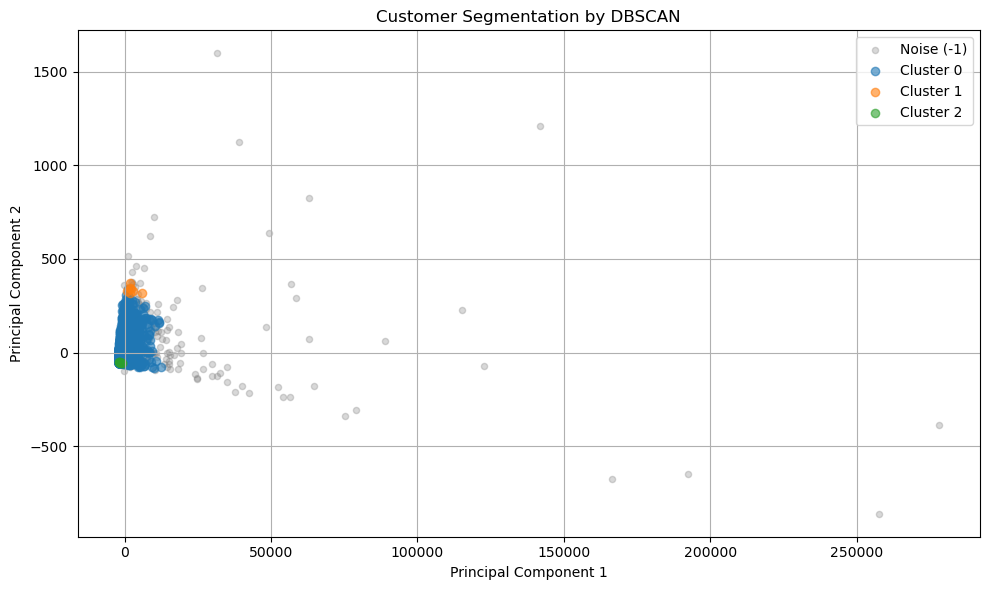

In [5]:
# 시각화
plt.figure(figsize=(10, 6))

# DBSCAN의 노이즈 -1로 표시
unique_clusters = sorted(df['DBSCAN_Cluster'].unique())
for cluster in unique_clusters:
    subset = df[df['DBSCAN_Cluster'] == cluster]
    if cluster == -1:
        plt.scatter(subset['PC1'], subset['PC2'], label='Noise (-1)', color='grey', alpha=0.3, s=20)
    else:
        plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title('Customer Segmentation by DBSCAN')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()